                                             Cognifyz: Internship Program in the field of Data Science

LEVEL1 - TASK3 : Geospatial Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set(color_codes=True)
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore")

file_path = r"E:\COLLEGGE\6 SEMESTER\Internship cognifyz\Dataset .csv"


try:
     dataset = pd.read_csv(file_path, sep=",", on_bad_lines='skip', encoding="utf-8-sig")
     print("FILE READ SUCESSFULLY")
except FileNotFoundError:
     print(f"File not found: {file_path}")

FILE READ SUCESSFULLY


In [3]:
dataset.head(2)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Create Point geometries from longitude and latitude
geometry = [Point(xy) for xy in zip(dataset['Longitude'], dataset['Latitude'])]
gdf = gpd.GeoDataFrame(dataset, geometry=geometry)

print("done   ")

done   


In [5]:
world = gpd.read_file(r"E:\COLLEGGE\6 SEMESTER\Internship cognifyz\ne_110m_admin_0_countries.shp")

# Plot the data
print("done")


done


<Figure size 2000x1500 with 0 Axes>

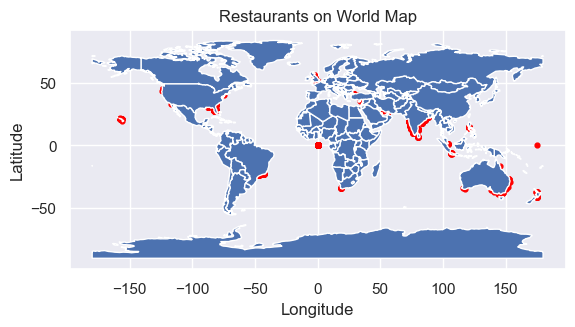

In [6]:
plt.figure(figsize=(20, 15))
world.plot(ax=gdf.plot("continents", marker="o", markersize=12, color='red', legend=True))
plt.title("Restaurants on World Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

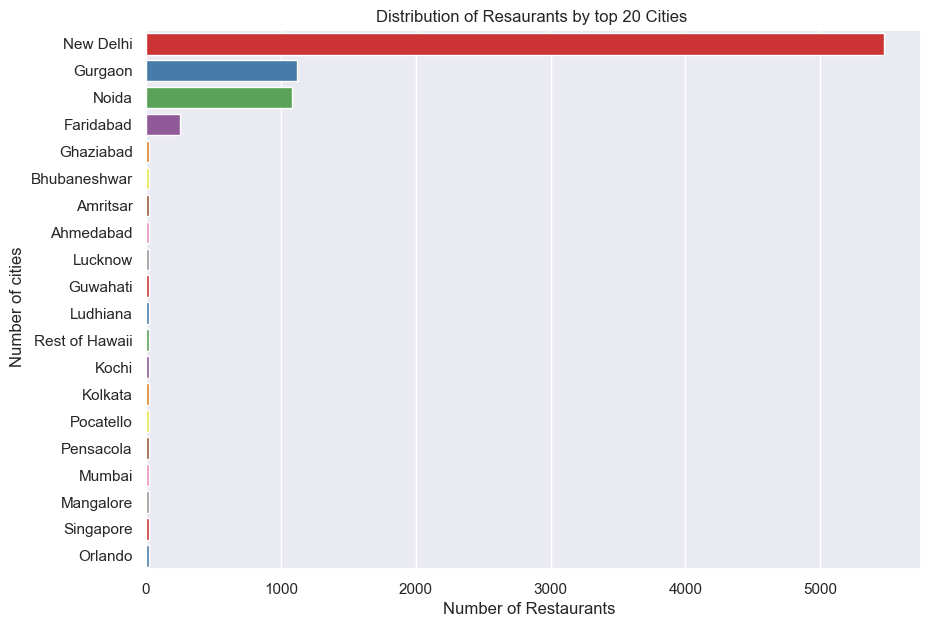

In [7]:
plt.figure(figsize=(10,7))
sns.countplot(y=dataset["City"],palette="Set1" ,data=dataset , order=dataset["City"].value_counts().head(20).index)
plt.title("Distribution of Resaurants by top 20 Cities ")
plt.ylabel("Number of cities   ")
plt.xlabel("Number of Restaurants  ")
#plt.xticks(rotation=45)
plt.show()

 Determine if there is any correlation
 between the restaurant's location and its
 rating.

In [13]:
numeric_dataset = dataset[["Longitude", "Latitude", "Aggregate rating"]].apply(pd.to_numeric, errors='coerce')
numeric_dataset = numeric_dataset.fillna(numeric_dataset.mean())


In [14]:
print(numeric_dataset.head())


    Longitude   Latitude  Aggregate rating
0  121.027535  14.565443               4.8
1  121.014101  14.553708               4.5
2  121.056831  14.581404               4.4
3  121.056475  14.585318               4.9
4  121.057508  14.584450               4.8


In [15]:
co_rela_matrx = numeric_dataset.corr()
print(co_rela_matrx)


                  Longitude  Latitude  Aggregate rating
Longitude          1.000000  0.043207         -0.116818
Latitude           0.043207  1.000000          0.000516
Aggregate rating  -0.116818  0.000516          1.000000


In [35]:
cor=co_rela_matrx
cor.style.background_gradient(cmap="coolwarm")

,Longitude,Latitude,Aggregate rating
Longitude,1.000000,0.043207,-0.116818
Latitude,0.043207,1.000000,0.000516
Aggregate rating,-0.116818,0.000516,1.000000
